In [ ]:
!pip install qrcode pyzbar python-barcode
!sudo apt-get install zbar-tools
!wget https://github.com/ChanCheeKean/datasets/blob/main/images/basic_cv.zip?raw=true
!wget https://moderncomputervision.s3.eu-west-2.amazonaws.com/images.zip
!wget https://moderncomputervision.s3.eu-west-2.amazonaws.com/videos.zip
!wget https://moderncomputervision.s3.eu-west-2.amazonaws.com/haarcascades.zip
!wget https://moderncomputervision.s3.eu-west-2.amazonaws.com/shape_predictor_68_face_landmarks.zip

!unzip -qq haarcascades.zip
!unzip -qq videos.zip
!unzip -qq images.zip
!unzip -qq basic_cv.zip?raw=true
!unzip -qq shape_predictor_68_face_landmarks.zip
!wget 'https://raw.githubusercontent.com/avelino/python-opencv-detect/master/haarcascade_eye.xml'
!wget 'https://raw.githubusercontent.com/kipr/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml'
!wget 'https://raw.githubusercontent.com/spmallick/mallick_cascades/master/haarcascades/haarcascade_russian_plate_number.xml'

In [1]:
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML
import dlib
from base64 import b64encode

import warnings
warnings.filterwarnings("ignore")

In [2]:
def imshow(title="Image", image=None, size=10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w / h
    plt.figure(figsize=(size * aspect_ratio, size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

# 1) Template Matching

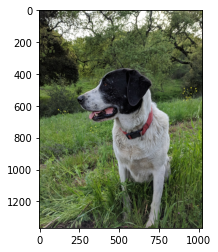

In [ ]:
full = cv2.imread("basic_cv/sammy.jpg")
full = cv2.cvtColor(full, cv2.COLOR_BGR2RGB)
plt.imshow(full)

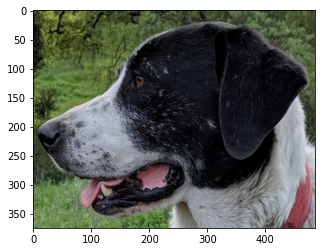

In [ ]:
face = cv2.imread("basic_cv/sammy_face.jpg")
face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
plt.imshow(face)

In [ ]:
# All the 6 methods for comparison in a list
# Note how we are using strings, later on we'll use the eval() function to convert to function
methods = [
    "cv2.TM_CCOEFF",
    "cv2.TM_CCOEFF_NORMED",
    "cv2.TM_CCORR",
    "cv2.TM_CCORR_NORMED",
    "cv2.TM_SQDIFF",
    "cv2.TM_SQDIFF_NORMED",
]

In [ ]:
# eval method
myfunc = eval("sum")
myfunc([1, 2, 3])

6

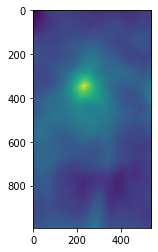

In [ ]:
# test out one of the method
method = eval("cv2.TM_CCOEFF")
# Apply template Matching with the method
res = cv2.matchTemplate(full, face, method)
plt.imshow(res)

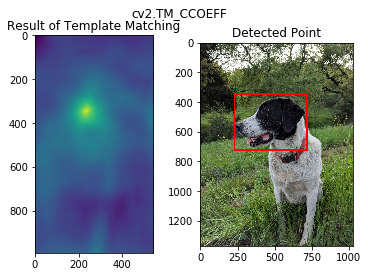

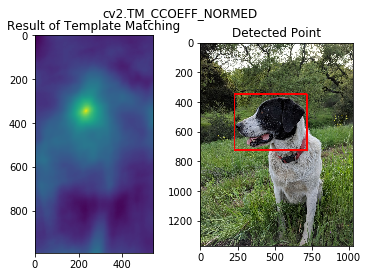

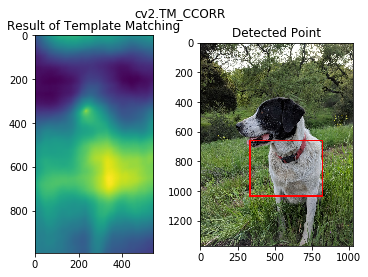

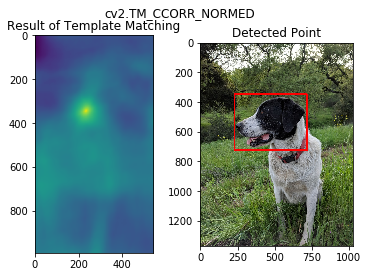

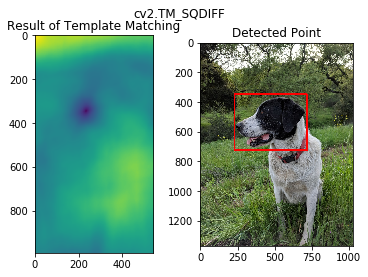

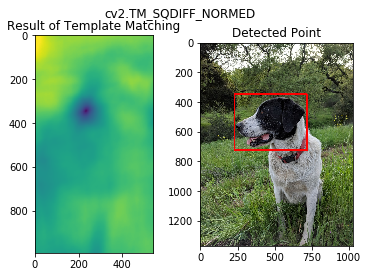

In [ ]:
height, width, hannels = face.shape
for m in methods:
    # Create a copy of the image
    full_copy = full.copy()

    # Get the actual function instead of the string
    method = eval(m)

    # Apply template Matching with the method
    res = cv2.matchTemplate(full_copy, face, method)

    # Grab the Max and Min values, plus their locations, to draw rectangle
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)

    # Set up drawing of Rectangle
    # If the method is TM_SQDIFF or TM_SQDIFF_NORMED, take minimum
    # Notice the coloring on the last 2 left hand side images.
    if method in [cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED]:
        top_left = min_loc
    else:
        top_left = max_loc

    # top_left = min_loc

    # Assign the Bottom Right of the rectangle
    bottom_right = (top_left[0] + width, top_left[1] + height)

    # Draw the Red Rectangle
    cv2.rectangle(full_copy, top_left, bottom_right, 255, 10)

    # Plot the Images
    plt.subplot(121)
    plt.imshow(res)
    plt.title("Result of Template Matching")

    plt.subplot(122)
    plt.imshow(full_copy)
    plt.title("Detected Point")
    plt.suptitle(m)

    plt.show()
    print("\n")
    print("\n")

# 2) Corner Detection

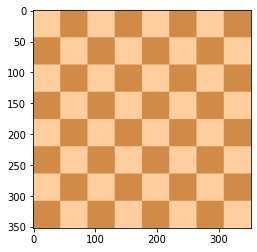

In [ ]:
flat_chess = cv2.imread("basic_cv/flat_chessboard.png")
flat_chess = cv2.cvtColor(flat_chess, cv2.COLOR_BGR2RGB)
plt.imshow(flat_chess)

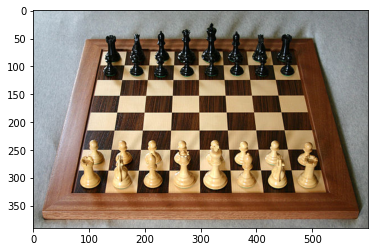

In [ ]:
real_chess = cv2.imread("basic_cv/real_chessboard.jpg")
real_chess = cv2.cvtColor(real_chess, cv2.COLOR_BGR2RGB)
plt.imshow(real_chess)

## 2.1 Harris Corner Detection

**cornerHarris Function**

*  src Input single-channel 8-bit or floating-point image.
*  dst Image to store the Harris detector responses. It has the type CV_32FC1 and the same size as src .
*  blockSize Neighborhood size (see the details on #cornerEigenValsAndVecs ).
*  ksize Aperture parameter for the Sobel operator.
*  k Harris detector free parameter. See the formula in DocString
*  borderType Pixel extrapolation method. See #BorderTypes.

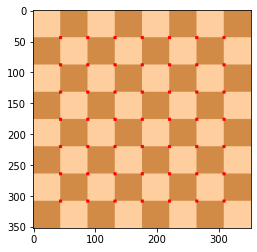

In [ ]:
# Need to reset the images since we drew on them
flat_chess = cv2.imread("basic_cv/flat_chessboard.png")
flat_chess = cv2.cvtColor(flat_chess, cv2.COLOR_BGR2RGB)
gray_flat_chess = cv2.cvtColor(flat_chess, cv2.COLOR_BGR2GRAY)

# Convert Gray Scale Image to Float Values
gray = np.float32(gray_flat_chess)

# Corner Harris Detection
dst = cv2.cornerHarris(src=gray, blockSize=2, ksize=3, k=0.04)

# result is dilated for marking the corners, not important to actual corner detection
# this is just so we can plot out the points on the image shown
dst = cv2.dilate(dst, None)

# Threshold for an optimal value, it may vary depending on the image.
flat_chess[dst > 0.01 * dst.max()] = [255, 0, 0]

plt.imshow(flat_chess)

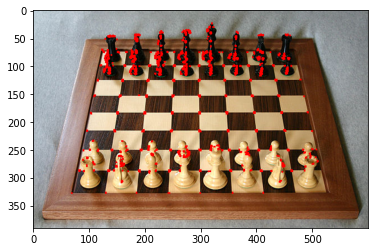

In [ ]:
# Convert Gray Scale Image to Float Values
gray_real_chess = cv2.cvtColor(real_chess, cv2.COLOR_BGR2GRAY)
gray = np.float32(gray_real_chess)

# Corner Harris Detection
dst = cv2.cornerHarris(src=gray, blockSize=2, ksize=3, k=0.04)

# result is dilated for marking the corners, not important to actual corner detection
# this is just so we can plot out the points on the image shown
dst = cv2.dilate(dst, None)

# Threshold for an optimal value, it may vary depending on the image.
real_chess[dst > 0.01 * dst.max()] = [255, 0, 0]

plt.imshow(real_chess)

## 2.2 Shi-Tomasi Corner Detector & Good Features to Track Paper

[Link to Paper from Video](http://www.ai.mit.edu/courses/6.891/handouts/shi94good.pdf)

goodFeatureToTrack Function Parameters

* image Input 8-bit or floating-point 32-bit, single-channel image.
* corners Output vector of detected corners.
* maxCorners Maximum number of corners to return. If there are more corners than are found,the strongest of them is returned. `maxCorners <= 0` implies that no limit on the maximum is set and all detected corners are returned. -1 for no limit
* qualityLevel Parameter characterizing the minimal accepted quality of image corners. The parameter value is multiplied by the best corner quality measure, which is the minimal eigenvalue (see #cornerMinEigenVal ) or the Harris function response (see #cornerHarris ). The corners with the quality measure less than the product are rejected. For example, if the best corner has the quality measure = 1500, and the qualityLevel=0.01 , then all the corners with the quality measure less than 15 are rejected.

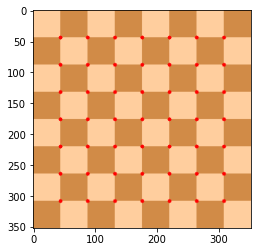

In [ ]:
corners = cv2.goodFeaturesToTrack(gray_flat_chess, 64, 0.01, 10)
corners = np.int0(corners)

for i in corners:
    x, y = i.ravel()
    cv2.circle(flat_chess, (x, y), 3, 255, -1)

plt.imshow(flat_chess)

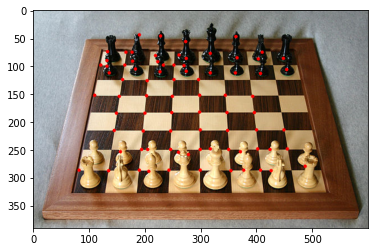

In [ ]:
real_chess = cv2.imread("basic_cv/real_chessboard.jpg")
real_chess = cv2.cvtColor(real_chess, cv2.COLOR_BGR2RGB)
gray_real_chess = cv2.cvtColor(real_chess, cv2.COLOR_BGR2GRAY)

corners = cv2.goodFeaturesToTrack(gray_real_chess, 80, 0.01, 10)
corners = np.int0(corners)

for i in corners:
    x, y = i.ravel()
    cv2.circle(real_chess, (x, y), 3, 255, -1)

plt.imshow(real_chess)

# 3) Edge Detection

## 3.1 Canny Edge Detection

https://en.wikipedia.org/wiki/Canny_edge_detector

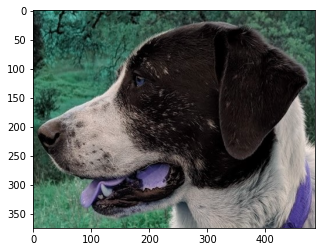

In [ ]:
img = cv2.imread("basic_cv/sammy_face.jpg")
plt.imshow(img)

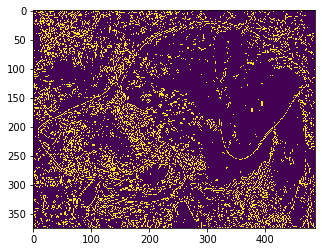

In [ ]:
edges = cv2.Canny(image=img, threshold1=127, threshold2=127)
plt.imshow(edges)

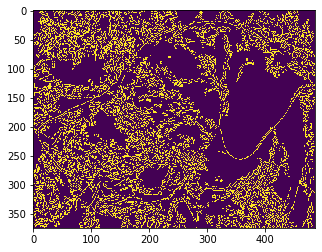

In [ ]:
edges = cv2.Canny(image=img, threshold1=0, threshold2=255)
plt.imshow(edges)

## 3.2. Choosing Thresholds

https://stackoverflow.com/questions/25125670/best-value-for-threshold-in-canny

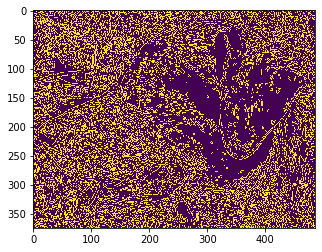

In [ ]:
med_val = np.median(img)
lower = int(max(0, 0.7 * med_val))
upper = int(min(255, 1.3 * med_val))
edges = cv2.Canny(image=img, threshold1=lower, threshold2=upper)
plt.imshow(edges)

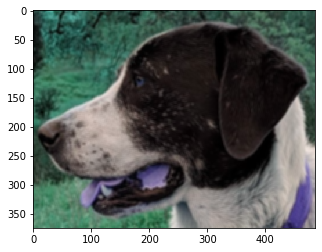

In [ ]:
blurred_img = cv2.blur(img, ksize=(5, 5))
plt.imshow(blurred_img)

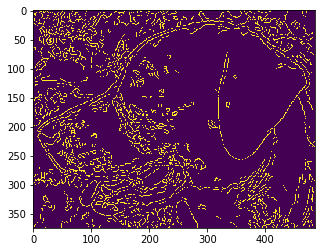

In [ ]:
edges = cv2.Canny(image=blurred_img, threshold1=lower, threshold2=upper)
plt.imshow(edges)

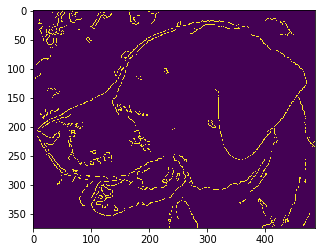

In [ ]:
edges = cv2.Canny(image=blurred_img, threshold1=lower, threshold2=upper + 80)
plt.imshow(edges)

# 4) Grid Detection

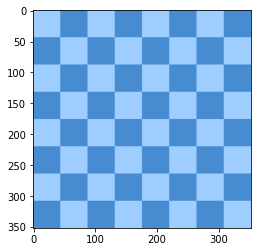

In [ ]:
flat_chess = cv2.imread("basic_cv/flat_chessboard.png")
plt.imshow(flat_chess, cmap="gray")

In [ ]:
found, corners = cv2.findChessboardCorners(flat_chess, (7, 7))

if found:
    print("OpenCV was able to find the corners")
else:
    print("OpenCV did not find corners. Double check your patternSize.")

print(corners.shape)

OpenCV was able to find the corners
(49, 1, 2)


In [ ]:
flat_chess_copy = flat_chess.copy()
cv2.drawChessboardCorners(flat_chess_copy, (7, 7), corners, found)

array([[[158, 206, 255],
        [158, 206, 255],
        [158, 206, 255],
        ...,
        [ 71, 139, 209],
        [ 71, 139, 209],
        [ 71, 139, 209]],

       [[158, 206, 255],
        [158, 206, 255],
        [158, 206, 255],
        ...,
        [ 71, 139, 209],
        [ 71, 139, 209],
        [ 71, 139, 209]],

       [[158, 206, 255],
        [158, 206, 255],
        [158, 206, 255],
        ...,
        [ 71, 139, 209],
        [ 71, 139, 209],
        [ 71, 139, 209]],

       ...,

       [[ 71, 139, 209],
        [ 71, 139, 209],
        [ 71, 139, 209],
        ...,
        [158, 206, 255],
        [158, 206, 255],
        [158, 206, 255]],

       [[ 71, 139, 209],
        [ 71, 139, 209],
        [ 71, 139, 209],
        ...,
        [158, 206, 255],
        [158, 206, 255],
        [158, 206, 255]],

       [[ 71, 139, 209],
        [ 71, 139, 209],
        [ 71, 139, 209],
        ...,
        [158, 206, 255],
        [158, 206, 255],
        [158, 206, 255]]

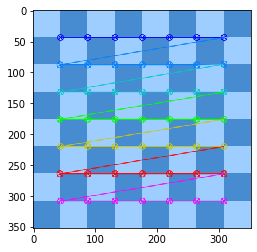

In [ ]:
plt.imshow(flat_chess_copy)

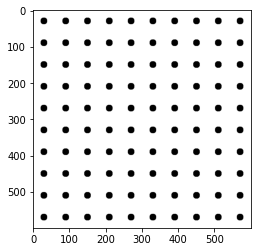

In [ ]:
# circle based grid
dots = cv2.imread("basic_cv/dot_grid.png")
plt.imshow(dots)

In [ ]:
found, corners = cv2.findCirclesGrid(dots, (10, 10), cv2.CALIB_CB_SYMMETRIC_GRID)
dbg_image_circles = dots.copy()
cv2.drawChessboardCorners(dbg_image_circles, (10, 10), corners, found)

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

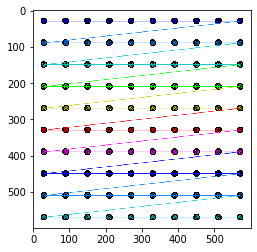

In [ ]:
plt.imshow(dbg_image_circles)

# 5) Contour Detection

## 5.1 CV Find Contour

function will return back contours in an image, and based on the RETR method called, you can get back external, internal, or both:

* cv2.RETR_EXTERNAL:Only extracts external contours
* cv2.RETR_CCOMP: Extracts both internal and external contours organized in a two-level hierarchy
* cv2.RETR_TREE: Extracts both internal and external contours organized in a  tree graph
* cv2.RETR_LIST: Extracts all contours without any internal/external relationship

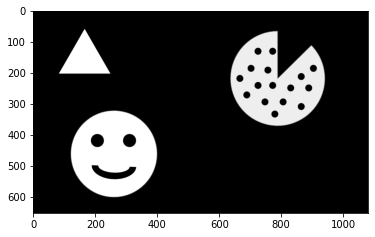

In [ ]:
img = cv2.imread("basic_cv/internal_external.png", 0)
plt.imshow(img, cmap="gray")

In [ ]:
contours, hierarchy = cv2.findContours(img, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
print(type(contours))
print(len(contours))
print(type(hierarchy))
print(hierarchy.shape)

<class 'list'>
22
<class 'numpy.ndarray'>
(1, 22, 4)


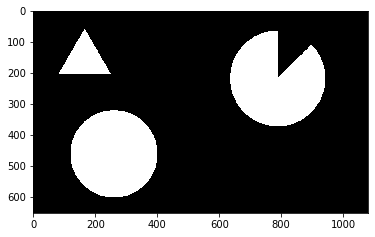

In [ ]:
# Draw External Contours

# Set up empty array
external_contours = np.zeros(img.shape)

# For every entry in contours
for i in range(len(contours)):
    # last column in the array is -1 if an external contour (no contours inside of it)
    if hierarchy[0][i][3] == -1:
        # We can now draw the external contours from the list of contours
        cv2.drawContours(external_contours, contours, i, 255, -1)

plt.imshow(external_contours, cmap="gray")

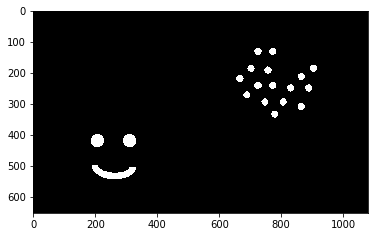

In [ ]:
# Create empty array to hold internal contours
image_internal = np.zeros(img.shape)

# Iterate through list of contour arrays
for i in range(len(contours)):
    # If third column value is NOT equal to -1 then its internal
    if hierarchy[0][i][3] != -1:

        # Draw the Contour
        cv2.drawContours(image_internal, contours, i, 255, -1)

plt.imshow(image_internal, cmap="gray")

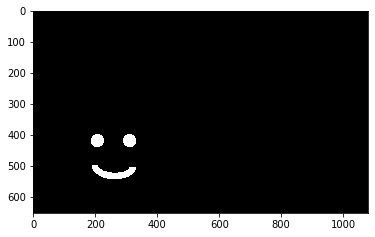

In [ ]:
# Create empty array to hold internal contours
image_internal = np.zeros(img.shape)

# Iterate through list of contour arrays
for i in range(len(contours)):
    # show only smiley
    if hierarchy[0][i][3] == 0:

        # Draw the Contour
        cv2.drawContours(image_internal, contours, i, 255, -1)

plt.imshow(image_internal, cmap="gray")

## 5.2 Contour Area

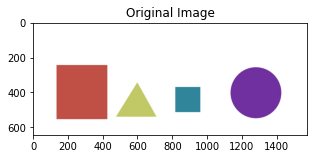

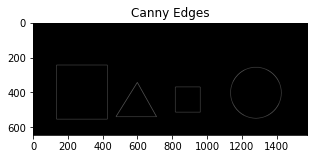

Number of contours found =  4


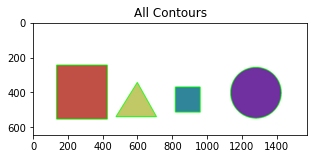

In [ ]:
# Load our image
image = cv2.imread("images/bunchofshapes.jpg")
imshow("Original Image", image)

# Grayscale image and Canny edges
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
edged = cv2.Canny(gray, 50, 200)
imshow("Canny Edges", edged)

# Find contours and print how many were found
contours, hierarchy = cv2.findContours(
    edged.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE
)
print("Number of contours found = ", len(contours))

# Draw all contours over blank image
cv2.drawContours(image, contours, -1, (0, 255, 0), 3)
imshow("All Contours", image)

Contour Area:  [20587.5, 22901.5, 66579.5, 90222.0]


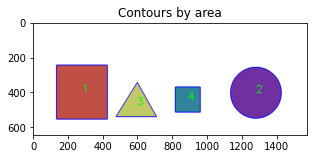

In [ ]:
# Function we'll use to display contour area
def get_contour_areas(contours):
    """returns the areas of all contours as list"""
    all_areas = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        all_areas.append(area)
    return all_areas


# find area of contours
image = cv2.imread("images/bunchofshapes.jpg")
print("Contour Area: ", get_contour_areas(contours))
sorted_contours = sorted(contours, key=cv2.contourArea, reverse=True)

# Iterate over our contours and draw one at a time
for i, c in enumerate(sorted_contours):
    M = cv2.moments(c)
    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])
    cv2.putText(
        image, str(i + 1), (cx, cy), cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 255, 0), 3
    )
    cv2.drawContours(image, [c], -1, (255, 0, 0), 3)

imshow("Contours by area", image)

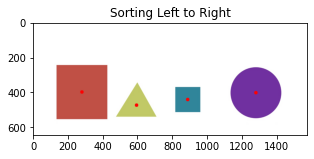

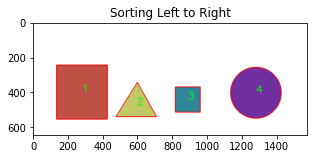

In [ ]:
### use Moments to Calculate the Center and then use the X Cordinate to sort from left to right
def x_cord_contour(contours):
    """Returns the X cordinate for the contour centroid"""
    if cv2.contourArea(contours) > 10:
        M = cv2.moments(contours)
        return int(M["m10"] / M["m00"])
    else:
        pass


def label_contour_center(image, c):
    """Places a red circle on the centers of contours"""
    M = cv2.moments(c)
    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])

    # Draw the countour number on the image
    cv2.circle(image, (cx, cy), 10, (0, 0, 255), -1)
    return image


image = cv2.imread("images/bunchofshapes.jpg")
orginal_image = image.copy()

# Computer Center of Mass or centroids and draw them on our image
for i, c in enumerate(contours):
    orig = label_contour_center(image, c)

# Showing the Contour centers
imshow("Sorting Left to Right", image)

# Sort by left to right using our x_cord_contour function
contours_left_to_right = sorted(contours, key=x_cord_contour, reverse=False)

# Labeling Contours left to right
for i, c in enumerate(contours_left_to_right):
    cv2.drawContours(orginal_image, [c], -1, (0, 0, 255), 3)
    M = cv2.moments(c)
    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])
    cv2.putText(
        orginal_image, str(i + 1), (cx, cy), cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 255, 0), 3
    )
    x, y, w, h = cv2.boundingRect(c)

imshow("Sorting Left to Right", orginal_image)

## 5.3 **Approximating Contours using ApproxPolyDP**
It approximates a contour shape to another shape with less number of vertices depending upon the precision we specify.

***cv2.approxPolyDP(contour, Approximation Accuracy, Closed)***
- **contour** – is the individual contour we wish to approximate
- **Approximation Accuracy** – Important parameter is determining the accuracy of the approximation. Small values give precise-  approximations, large values give more generic approximation. A good rule of thumb is less than 5% of the contour perimeter
- **Closed** – a Boolean value that states whether the approximate contour should be open or closed

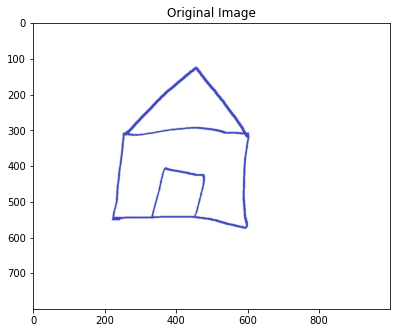

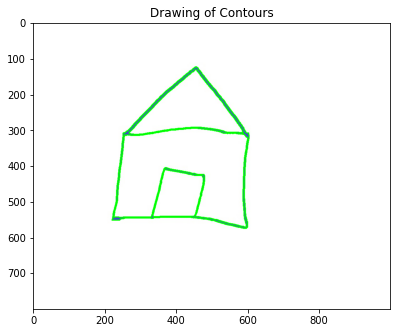

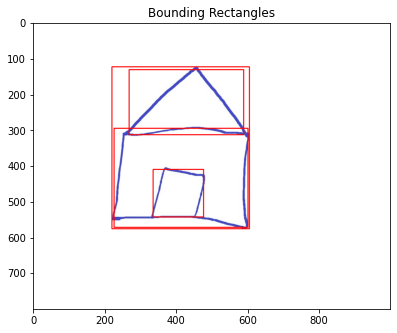

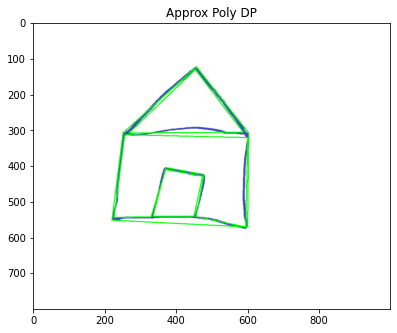

In [ ]:
# Load image and keep a copy
image = cv2.imread("images/house.jpg")
orig_image = image.copy()
imshow("Original Image", orig_image, 8)

# Grayscale and binarize
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

# Find contours
contours, hierarchy = cv2.findContours(
    thresh.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE
)
copy = image.copy()

# Iterate through each contour
for c in contours:
    x, y, w, h = cv2.boundingRect(c)
    cv2.rectangle(orig_image, (x, y), (x + w, y + h), (0, 0, 255), 2)
    cv2.drawContours(image, [c], 0, (0, 255, 0), 2)

imshow("Drawing of Contours", image, 8)
imshow("Bounding Rectangles", orig_image, 8)
# Iterate through each contour and compute the approx contour
for c in contours:
    # Calculate accuracy as a percent of the contour perimeter
    accuracy = 0.03 * cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, accuracy, True)
    cv2.drawContours(copy, [approx], 0, (0, 255, 0), 2)

imshow("Approx Poly DP", copy, 8)

## 5.4 Convex Hull

<img src="https://github.com/rajeevratan84/ModernComputerVision/raw/main/convex.png" width=500>

Convex Hull will look similar to contour approximation, but it is not (Both may provide the same results in some cases). 

The cv2.convexHull() function checks a curve for convexity defects and corrects it. Generally speaking, convex curves are the curves which are always bulged out, or at-least flat. And if it is bulged inside, it is called convexity defects. For example, check the below image of hand. Red line shows the convex hull of hand. The double-sided arrow marks shows the convexity defects, which are the local maximum deviations of hull from contours

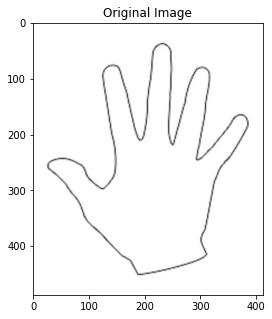

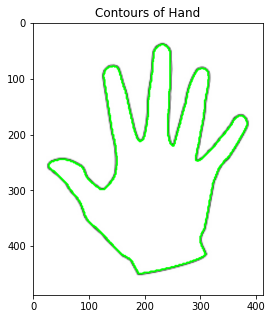

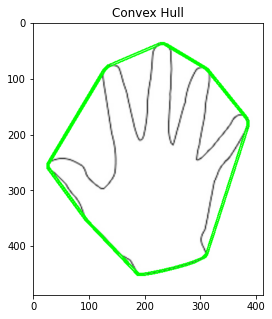

In [ ]:
image = cv2.imread("images/hand.jpg")
orginal_image = image.copy()
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

imshow("Original Image", image, 5)

# Threshold the image
ret, thresh = cv2.threshold(gray, 176, 255, 0)

# Find contours
contours, hierarchy = cv2.findContours(
    thresh.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE
)
cv2.drawContours(image, contours, 0, (0, 255, 0), 2)
imshow("Contours of Hand", image, 5)

# Sort Contors by area and then remove the largest frame contour
n = len(contours) - 1
contours = sorted(contours, key=cv2.contourArea, reverse=False)[:n]

# Iterate through contours and draw the convex hull
for c in contours:
    hull = cv2.convexHull(c)
    cv2.drawContours(orginal_image, [hull], 0, (0, 255, 0), 2)

imshow("Convex Hull", orginal_image, 5)

## 5.5 Matching Contours

**cv2.matchShapes(contour template, contour, method, method parameter)**

**Output** – match value (lower values means a closer match)

- Contour Template – This is our reference contour that we’re trying to find in the new image
- Contour – The individual contour we are checking against
- Method – Type of contour matching (1, 2, 3)
- Method Parameter – leave alone as 0.0 (not fully utilized in python OpenCV)

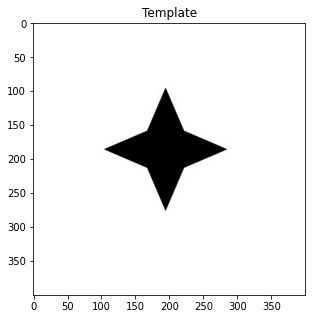

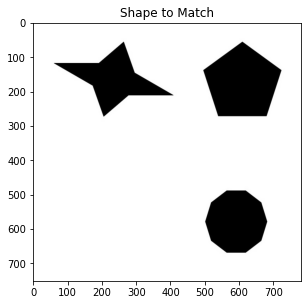

0.13081816783853514
0.15902005339788694
0.14987915682525596
0.07094034474475601


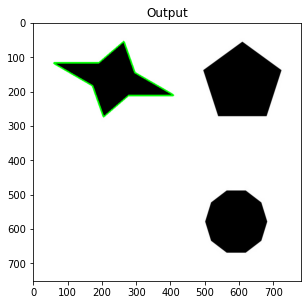

In [ ]:
# Load the shape template or reference image
template = cv2.imread("images/4star.jpg", 0)
imshow("Template", template, 5)

# Load the target image with the shapes we're trying to match
target = cv2.imread("images/shapestomatch.jpg")
target_gray = cv2.cvtColor(target, cv2.COLOR_BGR2GRAY)
imshow("Shape to Match", target_gray, 5)

# Threshold both images first before using cv2.findContours
ret, thresh1 = cv2.threshold(template, 127, 255, 0)
ret, thresh2 = cv2.threshold(target_gray, 127, 255, 0)

# Find contours in template
contours, hierarchy = cv2.findContours(thresh1, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)

# We need to sort the contours by area so that we can remove the largest
# contour which is the image outline
sorted_contours = sorted(contours, key=cv2.contourArea, reverse=True)

# We extract the second largest contour which will be our template contour
template_contour = contours[1]

# Extract contours from second target image
contours, hierarchy = cv2.findContours(thresh2, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)

for c in contours:
    # Iterate through each contour in the target image and
    # use cv2.matchShapes to compare contour shapes
    match = cv2.matchShapes(template_contour, c, 3, 0.0)
    print(match)
    # If the match value is less than 0.15 we
    if match < 0.15:
        closest_contour = c
    else:
        closest_contour = []

cv2.drawContours(target, [closest_contour], -1, (0, 255, 0), 3)
imshow("Output", target, 5)

## 5.6 Perspective Transform

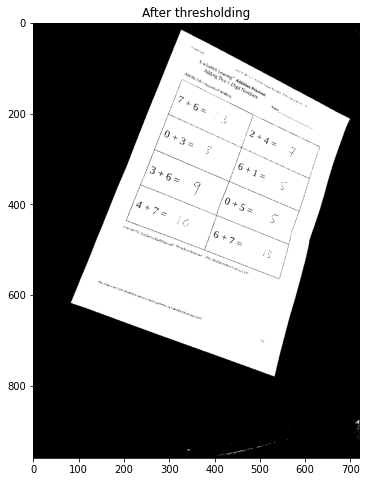

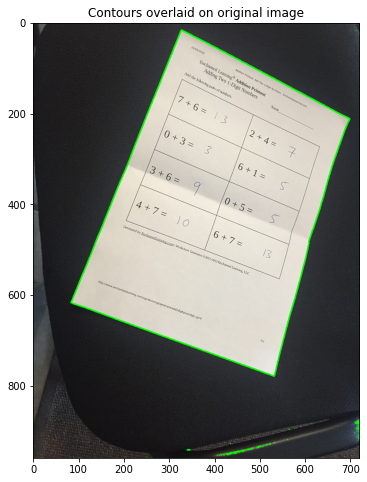

Number of Contours found = 54


In [ ]:
image = cv2.imread("images/scan.jpg")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
_, th2 = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
imshow("After thresholding", th2, size=8)

# find contour
contours, hierarchy = cv2.findContours(th2, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Draw all contours, note this overwrites the input image (inplace operation)
# Use '-1' as the 3rd parameter to draw all
cv2.drawContours(image, contours, -1, (0, 255, 0), thickness=2)
imshow("Contours overlaid on original image", image, size=8)
print("Number of Contours found = " + str(len(contours)))

In [ ]:
# we only want the contour with the 4 points

# Sort contours large to small by area
sorted_contours = sorted(contours, key=cv2.contourArea, reverse=True)

# loop over the contours
for cnt in sorted_contours:
    # approximate the contour
    perimeter = cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, 0.05 * perimeter, True)

    if len(approx) == 4:
        break

# Our x, y cordinates of the four corners
print("Our 4 corner points are:")
print(approx)

Our 4 corner points are:
[[[326  15]]

 [[ 83 617]]

 [[531 779]]

 [[697 211]]]


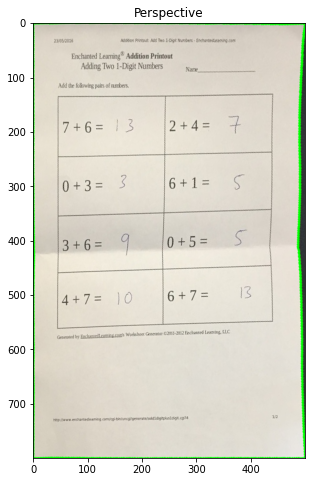

In [ ]:
# manally map, Use getPerspectiveTransform and warpPerspective to create our top down view
inputPts = np.float32(approx)
outputPts = np.float32([[0, 0], [0, 800], [500, 800], [500, 0]])

# Get our Transform Matrix, M
M = cv2.getPerspectiveTransform(inputPts, outputPts)
# Apply the transform Matrix M using Warp Perspective
dst = cv2.warpPerspective(image, M, (500, 800))

imshow("Perspective", dst, size=8)

# 6) Feature Matching

## 6.1 Brute Force Detection with ORB Descriptors

In [ ]:
def display(img, cmap="gray"):
    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot(111)
    ax.imshow(img, cmap="gray")


reeses = cv2.imread("basic_cv/reeses_puffs.png", 0)
display(reeses)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [ ]:
cereals = cv2.imread("basic_cv/many_cereals.jpg", 0)
display(cereals)

array([[ 78, 147, 164, ..., 129, 116,  48],
       [ 81,  89, 107, ..., 112, 116,  47],
       [ 83,  88,  80, ..., 102,  97,  70],
       ...,
       [116, 111, 106, ...,  87, 101, 126],
       [ 62,  58,  55, ...,  84,  93,  97],
       [ 59,  60,  60, ...,  85,  72,  77]], dtype=uint8)

In [ ]:
# Initiate ORB detector
orb = cv2.ORB_create()

# find the keypoints and descriptors with ORB
kp1, des1 = orb.detectAndCompute(reeses, mask=None)
kp2, des2 = orb.detectAndCompute(cereals, mask=None)

# create BFMatcher object
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

# Match descriptors.
matches = bf.match(des1, des2)

# Sort them in the order of their distance. Higher distance better match
matches = sorted(matches, key=lambda x: x.distance)
print(len(matches))
# Draw first 25 matches.
reeses_matches = cv2.drawMatches(
    reeses, kp1, cereals, kp2, matches[:250], None, flags=2
)

139


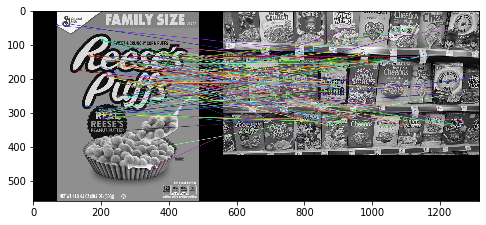

In [ ]:
display(reeses_matches)

# 7) Face Detection

In [ ]:
nadia = cv2.imread("basic_cv/Nadia_Murad.jpg", 0)
denis = cv2.imread("basic_cv/Denis_Mukwege.jpg", 0)
solvay = cv2.imread("basic_cv/solvay_conference.jpg", 0)

In [ ]:
def detect_face(img):
    face_img = img.copy()
    face_rects = face_cascade.detectMultiScale(face_img)
    for x, y, w, h in face_rects:
        cv2.rectangle(face_img, (x, y), (x + w, y + h), (255, 255, 255), 10)
    return face_img


# OpenCV comes with these pre-trained cascade files
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

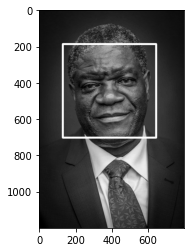

In [ ]:
result = detect_face(denis)
plt.imshow(result, cmap="gray")

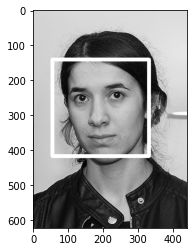

In [ ]:
result = detect_face(nadia)
plt.imshow(result, cmap="gray")

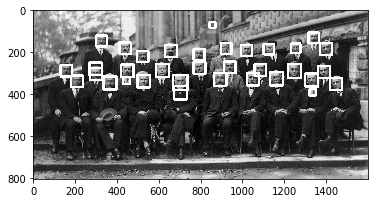

In [ ]:
# Gets errors! Add some parameters to solve it!
result = detect_face(solvay)
plt.imshow(result, cmap="gray")

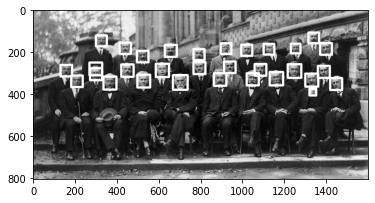

In [ ]:
def adj_detect_face(img):
    face_img = img.copy()
    # detect it as face when they are near!
    face_rects = face_cascade.detectMultiScale(
        face_img, scaleFactor=1.1, minNeighbors=5
    )
    for x, y, w, h in face_rects:
        cv2.rectangle(face_img, (x, y), (x + w, y + h), (255, 255, 255), 10)

    return face_img


# Doesn't detect the side face.
result = adj_detect_face(solvay)
plt.imshow(result, cmap="gray")

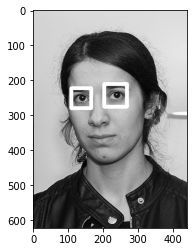

In [ ]:
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")


def detect_eyes(img):
    face_img = img.copy()
    eyes = eye_cascade.detectMultiScale(face_img)

    for x, y, w, h in eyes:
        cv2.rectangle(face_img, (x, y), (x + w, y + h), (255, 255, 255), 10)

    return face_img


result = detect_eyes(nadia)
plt.imshow(result, cmap="gray")

# 8) Car Plate Detection

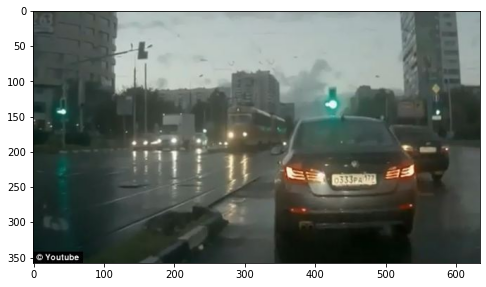

In [ ]:
def display(img):
    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot(111)
    new_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(new_img)


img = cv2.imread("basic_cv/car_plate.jpg")
display(img)

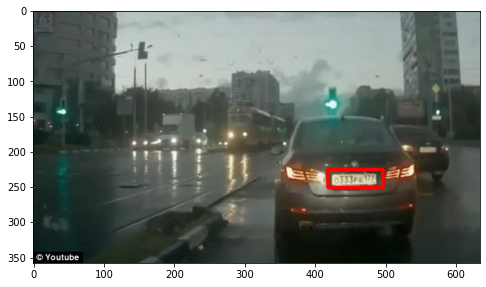

In [ ]:
plate_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_russian_plate_number.xml"
)


def detect_plate(img):
    plate_img = img.copy()
    plate_rects = plate_cascade.detectMultiScale(
        plate_img, scaleFactor=1.3, minNeighbors=3
    )

    for x, y, w, h in plate_rects:
        cv2.rectangle(plate_img, (x, y), (x + w, y + h), (0, 0, 255), 4)

    return plate_img


result = detect_plate(img)
display(result)

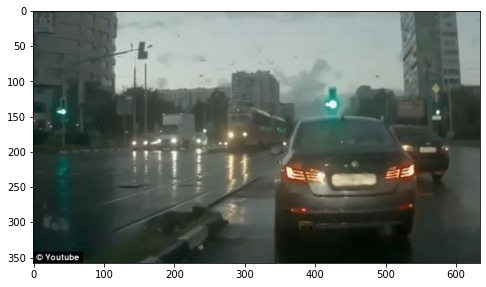

In [ ]:
# blurring the number plate
def detect_and_blur_plate(img):
    # Watch solutions video for line by line explanation!
    plate_img = img.copy()
    roi = img.copy()
    plate_rects = plate_cascade.detectMultiScale(
        plate_img, scaleFactor=1.3, minNeighbors=3
    )
    for x, y, w, h in plate_rects:
        roi = roi[y : y + h, x : x + w]
        blurred_roi = cv2.medianBlur(roi, 7)
        plate_img[y : y + h, x : x + w] = blurred_roi
    return plate_img


result = detect_and_blur_plate(img)
display(result)

# 9) Vehicle Detection (Video)

In [ ]:
# load video and cascade
cap = cv2.VideoCapture("cars.mp4")
body_detector = cv2.CascadeClassifier("Haarcascades/haarcascade_car.xml")

# Get the height and width of the frame
w = int(cap.get(3))
h = int(cap.get(4))

# Define the codec and create VideoWriter object and output files
# MJPG, fps, size
out = cv2.VideoWriter(
    "cars_output.avi", cv2.VideoWriter_fourcc("M", "J", "P", "G"), 30, (w, h)
)

while True:
    ret, frame = cap.read()
    if ret:
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        bodies = body_detector.detectMultiScale(gray, 1.2, 3)
        for x, y, w, h in bodies:
            cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 255), 2)

        # Write the frame into the file 'output.avi'
        out.write(frame)
    else:
        break

cap.release()
out.release()

In [ ]:
# colab can only run mp4 file so convert the AVI file to MP4 using FFMPEG
!ffmpeg -i /content/cars_output.avi cars_output.mp4 -y

In [ ]:
# boiler plate to read and play video
mp4 = open("cars_output.mp4", "rb").read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML("""
<video controls>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)

# 10) Facial LandMark Detection

## 10.1 Face Detection
The landmark will always give the same number, e.g. face - 17, 27 - nose, 35 - lips

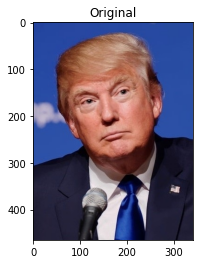

Detected Face: rectangles[[(77, 98) (262, 284)]]


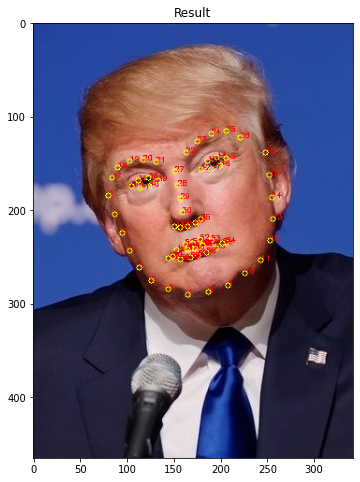

In [ ]:
PREDICTOR_PATH = "shape_predictor_68_face_landmarks.dat"
predictor = dlib.shape_predictor(PREDICTOR_PATH)
detector = dlib.get_frontal_face_detector()


def get_landmarks(im):
    rects = detector(im, 1)
    print(f"Detected Face: {rects}")

    if len(rects) > 1:
        raise "Too Many Faces"
    if len(rects) == 0:
        raise "No Faces Detected"

    return np.matrix([[p.x, p.y] for p in predictor(im, rects[0]).parts()])


def annotate_landmarks(im, landmarks):
    im = im.copy()
    for idx, point in enumerate(landmarks):
        pos = (point[0, 0], point[0, 1])
        cv2.putText(
            im,
            str(idx),
            pos,
            fontFace=cv2.FONT_HERSHEY_SCRIPT_SIMPLEX,
            fontScale=0.25,
            color=(0, 0, 255),
        )

        cv2.circle(im, pos, 3, color=(0, 255, 255))
    return im


image = cv2.imread("images/Trump.jpg")
imshow("Original", image, size=4)
landmarks = get_landmarks(image)
image_with_landmarks = annotate_landmarks(image, landmarks)
imshow("Result", image_with_landmarks, size=8)

Detected Face: rectangles[[(20, 56) (127, 163)]]


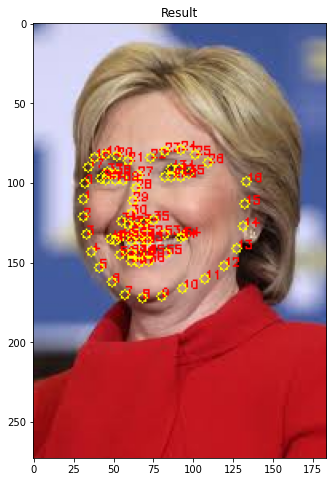

In [ ]:
image = cv2.imread("images/Hillary.jpg")
landmarks = get_landmarks(image)
image_with_landmarks = annotate_landmarks(image, landmarks)
imshow("Result", image_with_landmarks, size=8)

## 10.2 Face Swapping

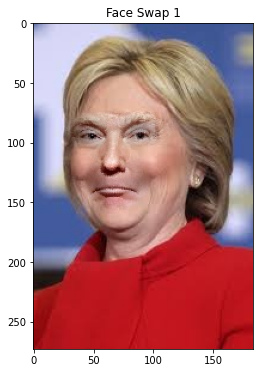

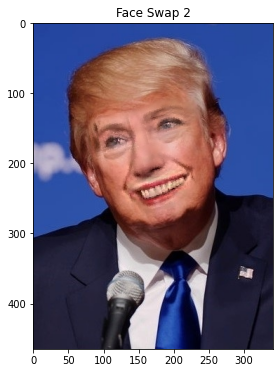

In [ ]:
PREDICTOR_PATH = "shape_predictor_68_face_landmarks.dat"
SCALE_FACTOR = 1
FEATHER_AMOUNT = 11

FACE_POINTS = list(range(17, 68))
MOUTH_POINTS = list(range(48, 61))
RIGHT_BROW_POINTS = list(range(17, 22))
LEFT_BROW_POINTS = list(range(22, 27))
RIGHT_EYE_POINTS = list(range(36, 42))
LEFT_EYE_POINTS = list(range(42, 48))
NOSE_POINTS = list(range(27, 35))
JAW_POINTS = list(range(0, 17))

# Points used to line up the images.
ALIGN_POINTS = (
    LEFT_BROW_POINTS
    + RIGHT_EYE_POINTS
    + LEFT_EYE_POINTS
    + RIGHT_BROW_POINTS
    + NOSE_POINTS
    + MOUTH_POINTS
)

# Points from the second image to overlay on the first. The convex hull of each element will be overlaid.
OVERLAY_POINTS = [
    LEFT_EYE_POINTS + RIGHT_EYE_POINTS + LEFT_BROW_POINTS + RIGHT_BROW_POINTS,
    NOSE_POINTS + MOUTH_POINTS,
]

# Amount of blur to use during colour correction, as a fraction of the pupillary distance.
COLOUR_CORRECT_BLUR_FRAC = 0.6
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor(PREDICTOR_PATH)


def get_landmarks(im):
    # Returns facial landmarks as (x,y) coordinates
    rects = detector(im, 1)
    if len(rects) > 1:
        raise ""
    if len(rects) == 0:
        raise ""
    return np.matrix([[p.x, p.y] for p in predictor(im, rects[0]).parts()])


def annotate_landmarks(im, landmarks):
    im = im.copy()
    for idx, point in enumerate(landmarks):
        pos = (point[0, 0], point[0, 1])
        cv2.putText(
            im,
            str(idx),
            pos,
            fontFace=cv2.FONT_HERSHEY_SCRIPT_SIMPLEX,
            fontScale=0.4,
            color=(0, 0, 255),
        )
        cv2.circle(im, pos, 3, color=(0, 255, 255))
    return im


def draw_convex_hull(im, points, color):
    points = cv2.convexHull(points)
    cv2.fillConvexPoly(im, points, color=color)


def get_face_mask(im, landmarks):
    im = np.zeros(im.shape[:2], dtype=np.float64)
    for group in OVERLAY_POINTS:
        draw_convex_hull(im, landmarks[group], color=1)

    im = np.array([im, im, im]).transpose((1, 2, 0))
    im = (cv2.GaussianBlur(im, (FEATHER_AMOUNT, FEATHER_AMOUNT), 0) > 0) * 1.0
    im = cv2.GaussianBlur(im, (FEATHER_AMOUNT, FEATHER_AMOUNT), 0)
    return im


def transformation_from_points(points1, points2):
    """
    Return an affine transformation [s * R | T] such that:
        sum ||s*R*p1,i + T - p2,i||^2
    is minimized.
    """
    # Solve the procrustes problem by subtracting centroids,
    # scaling by the standard deviation, and then using the SVD to calculate the rotation

    points1 = points1.astype(np.float64)
    points2 = points2.astype(np.float64)
    c1 = np.mean(points1, axis=0)
    c2 = np.mean(points2, axis=0)
    points1 -= c1
    points2 -= c2
    s1 = np.std(points1)
    s2 = np.std(points2)
    points1 /= s1
    points2 /= s2
    U, S, Vt = np.linalg.svd(points1.T * points2)

    # The R we seek is in fact the transpose of the one given by U * Vt.
    # This is because the above formulation assumes the matrix goes on the right
    # (with row vectors) where as our solution requires the matrix to be on the left (with column vectors).
    R = (U * Vt).T

    return np.vstack(
        [
            np.hstack(((s2 / s1) * R, c2.T - (s2 / s1) * R * c1.T)),
            np.matrix([0.0, 0.0, 1.0]),
        ]
    )


def read_im_and_landmarks(image):
    im = image
    im = cv2.resize(im, None, fx=1, fy=1, interpolation=cv2.INTER_LINEAR)
    im = cv2.resize(im, (im.shape[1] * SCALE_FACTOR, im.shape[0] * SCALE_FACTOR))
    s = get_landmarks(im)
    return im, s


def warp_im(im, M, dshape):
    output_im = np.zeros(dshape, dtype=im.dtype)
    cv2.warpAffine(
        im,
        M[:2],
        (dshape[1], dshape[0]),
        dst=output_im,
        borderMode=cv2.BORDER_TRANSPARENT,
        flags=cv2.WARP_INVERSE_MAP,
    )
    return output_im


def correct_colours(im1, im2, landmarks1):
    blur_amount = COLOUR_CORRECT_BLUR_FRAC * np.linalg.norm(
        np.mean(landmarks1[LEFT_EYE_POINTS], axis=0)
        - np.mean(landmarks1[RIGHT_EYE_POINTS], axis=0)
    )
    blur_amount = int(blur_amount)
    if blur_amount % 2 == 0:
        blur_amount += 1
    im1_blur = cv2.GaussianBlur(im1, (blur_amount, blur_amount), 0)
    im2_blur = cv2.GaussianBlur(im2, (blur_amount, blur_amount), 0)

    # Avoid divide-by-zero errors.
    im2_blur += (128 * (im2_blur <= 1.0)).astype(im2_blur.dtype)
    return (
        im2.astype(np.float64)
        * im1_blur.astype(np.float64)
        / im2_blur.astype(np.float64)
    )


def swappy(image1, image2):
    im1, landmarks1 = read_im_and_landmarks(image1)
    im2, landmarks2 = read_im_and_landmarks(image2)
    M = transformation_from_points(landmarks1[ALIGN_POINTS], landmarks2[ALIGN_POINTS])
    mask = get_face_mask(im2, landmarks2)
    warped_mask = warp_im(mask, M, im1.shape)
    combined_mask = np.max([get_face_mask(im1, landmarks1), warped_mask], axis=0)
    warped_im2 = warp_im(im2, M, im1.shape)
    warped_corrected_im2 = correct_colours(im1, warped_im2, landmarks1)
    output_im = im1 * (1.0 - combined_mask) + warped_corrected_im2 * combined_mask
    cv2.imwrite("output.jpg", output_im)
    image = cv2.imread("output.jpg")
    return image


## Enter the paths to your input images here
image1 = cv2.imread("images/Hillary.jpg")
image2 = cv2.imread("images/Trump.jpg")

swapped = swappy(image1, image2)
imshow("Face Swap 1", swapped, size=6)

swapped = swappy(image2, image1)
imshow("Face Swap 2", swapped, size=6)

# 11) Barcode & QR Detection

In [27]:
from barcode import EAN13
from barcode.writer import ImageWriter
import qrcode
from PIL import Image
from pyzbar.pyzbar import decode
from PIL import Image
import requests
import io

## 11.1 Barcode

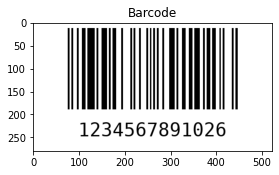

In [10]:
with open("barcode.png", "wb") as f:
    EAN13("123456789102", writer=ImageWriter()).write(f)

barcode = cv2.imread("barcode.png")
imshow("Barcode", barcode, size=8)

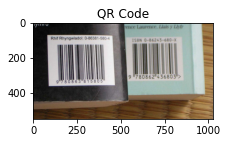

Barcode revealed: 9780863815805
Barcode revealed: 9780863815805


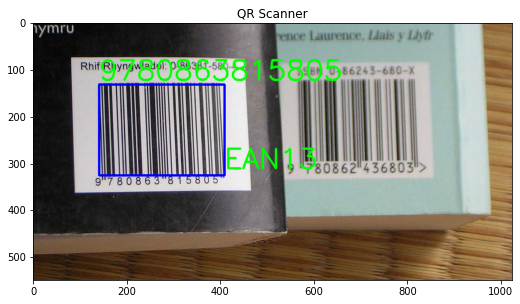

In [40]:
image_path = (
    "https://www.differencebetween.com/wp-content/uploads/2011/04/1024px-ISBN.jpg"
)
image = Image.open(io.BytesIO(requests.get(image_path, stream=True).content))
image.save("1024px-ISBN.jpg")
image = cv2.imread("1024px-ISBN.jpg")
imshow("QR Code", image, size=6)

# Detect and decode the qrcode
barcodes = decode(image)

# loop over the detected barcodes
for bc in barcodes:
    # Get the rect coordiantes for our text placement
    x, y, w, h = bc.rect
    cv2.rectangle(image, (x, y), (x + w, y + h), (255, 0, 0), 3)

    # extract the string info data and the type from our object
    barcode_text = bc.data.decode()
    barcode_type = bc.type

    # show our
    text = "{} ({})".format(barcode_text, barcode_type)
    cv2.putText(
        image, barcode_text, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 255, 0), 3
    )
    cv2.putText(
        image,
        barcode_type,
        (x + w, y + h - 15),
        cv2.FONT_HERSHEY_SIMPLEX,
        2,
        (0, 255, 0),
        3,
    )
    print("Barcode revealed: {}".format(barcode_text))
    print("Barcode revealed: {}".format(barcode_text))

# display our output
imshow("QR Scanner", image, size=16)

## 11.2 QR Code

Let's generate QR Codes using our qrcode package.

A QR code (abbreviated from Quick Response code) is a type of matrix barcode (or two-dimensional barcode) first designed in 1994 for the automotive industry in Japan. A barcode is a machine-readable optical label that contains information about the item to which it is attached. In practice, QR codes often contain data for a locator, identifier, or tracker that points to a website or application. A QR code uses four standardized encoding modes (numeric, alphanumeric, byte/binary, and kanji) to store data efficiently; extensions may also be used.

A QR code consists of black squares arranged in a square grid on a white background, which can be read by an imaging device such as a camera, and processed using Reed–Solomon error correction until the image can be appropriately interpreted. The required data is then extracted from patterns that are present in both horizontal and vertical components of the image.

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/1/1d/QR_Code_Structure_Example_3.svg/800px-QR_Code_Structure_Example_3.svg.png" width=500>

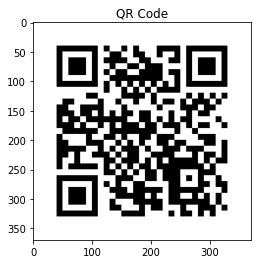

In [24]:
qr = qrcode.QRCode(
    version=1,
    error_correction=qrcode.constants.ERROR_CORRECT_H,
    box_size=10,
    border=4,
)

# turn url into qrcode
qr.add_data("https://wwww.opencv.org")
qr.make(fit=True)
img = qr.make_image(fill_color="black", back_color="white")
img.save("qrcode.png")
qr_code = cv2.imread("qrcode.png")
imshow("QR Code", qr_code, size=4)

**Configuartion for QR Codes**:

- version — Control the size of the QR Code. It accepts an integer from 1 to 40. Version 1 consists of 21 x 21 matrix.
- error_correction — Control the error correction used for the QR Code.
- box_size — Control the number of pixels of each boxes of the QR code.
- border — Control the boxes thickness of the border. The default is value is 4 which is also the minimum value according to the specification.

There are 4 constants available for error_correction. The higher errors can be corrected, the better it is.

- ERROR_CORRECT_L — About 7% or less errors can be corrected.
- ERROR_CORRECT_M — About 15% or less errors can be corrected. This is the default value.
- ERROR_CORRECT_Q — About 25% or less errors can be corrected.
- ERROR_CORRECT_H — About 30% or less errors can be corrected.

In [25]:
# decoding
img = Image.open("qrcode.png")
result = decode(img)
for i in result:
    print(i.data.decode("utf-8"))

https://wwww.opencv.org


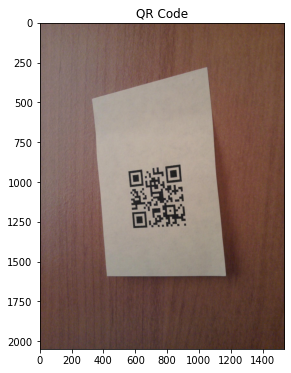

[Point(x=558, y=938), Point(x=587, y=1288), Point(x=915, y=1274), Point(x=878, y=896)]
QR Code revealed: http://ruthenus.pl (QRCODE)


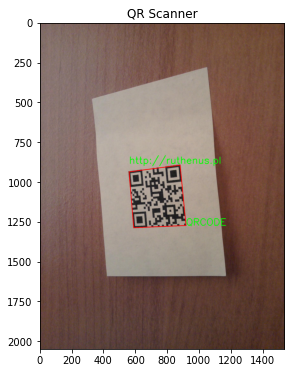

In [38]:
image_path = "https://i.stack.imgur.com/1DwED.jpg"
image = Image.open(io.BytesIO(requests.get(image_path, stream=True).content))
image.save("1DwED.jpg")
image = cv2.imread("1DwED.jpg")
imshow("QR Code", image, size=6)

# Detect and decode the qrcode
codes = decode(image)

# loop over the detected barcodes
for bc in codes:
    # Get the rect coordiantes for our text placement
    x, y, w, h = bc.rect
    print(bc.polygon)
    pt1, pt2, pt3, pt4 = bc.polygon

    # Draw a bounding box over our detected QR code
    pts = np.array(
        [[pt1.x, pt1.y], [pt2.x, pt2.y], [pt3.x, pt3.y], [pt4.x, pt4.y]], np.int32
    )
    pts = pts.reshape((-1, 1, 2))
    cv2.polylines(image, [pts], True, (0, 0, 255), 3)

    # extract the string info data and the type from our object
    barcode_text = bc.data.decode()
    barcode_type = bc.type

    # show our
    text = "{} ({})".format(barcode_text, barcode_type)
    cv2.putText(
        image, barcode_text, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 255, 0), 3
    )
    cv2.putText(
        image,
        barcode_type,
        (x + w, y + h - 15),
        cv2.FONT_HERSHEY_SIMPLEX,
        2,
        (0, 255, 0),
        3,
    )
    print("QR Code revealed: {}".format(text))

# display our output
imshow("QR Scanner", image, size=6)